In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
data = pd.read_csv(r"D:\my project\codeit_datascience\data_science\regression\data science\car cleaned data.csv")
data.head()

,Location,run,Name,fule,Transmission,Mileage,Engine,Power,price,Price
0,Mumbai,72000,Maruti Wagon R LXI CNG,CNG,Manual,26.60,998.0,58.16,NaN,1.75
1,Pune,41000,Hyundai Creta 1.6 CRDi SX Option,Diesel,Manual,19.67,1582.0,126.20,NaN,12.50
2,Chennai,46000,Honda Jazz V,Petrol,Manual,18.20,1199.0,88.70,8.61 Lakh,4.50
3,Chennai,87000,Maruti Ertiga VDI,Diesel,Manual,20.77,1248.0,88.76,NaN,6.00
4,Coimbatore,40670,Audi A4 New 2.0 TDI Multitronic,Diesel,Automatic,15.20,1968.0,140.80,NaN,17.74


In [7]:
data['brand']=data['Name'].str.split(' ', expand=True)[0]

In [8]:
data['model']=data['Name'].str.split(' ',expand=True)[1]

In [9]:
data.head()

,Location,run,Name,fule,Transmission,Mileage,Engine,Power,price,Price,brand,model
0,Mumbai,72000,Maruti Wagon R LXI CNG,CNG,Manual,26.60,998.0,58.16,NaN,1.75,Maruti,Wagon
1,Pune,41000,Hyundai Creta 1.6 CRDi SX Option,Diesel,Manual,19.67,1582.0,126.20,NaN,12.50,Hyundai,Creta
2,Chennai,46000,Honda Jazz V,Petrol,Manual,18.20,1199.0,88.70,8.61 Lakh,4.50,Honda,Jazz
3,Chennai,87000,Maruti Ertiga VDI,Diesel,Manual,20.77,1248.0,88.76,NaN,6.00,Maruti,Ertiga
4,Coimbatore,40670,Audi A4 New 2.0 TDI Multitronic,Diesel,Automatic,15.20,1968.0,140.80,NaN,17.74,Audi,A4


In [12]:
# Encoding
# Assigning a unique number to a categorial value in a column, so that machine can understand
data.Location.unique()

<StringArray>
[    'Mumbai',       'Pune',    'Chennai', 'Coimbatore',  'Hyderabad',
     'Jaipur',      'Kochi',    'Kolkata',      'Delhi',  'Bangalore',
  'Ahmedabad']
Length: 11, dtype: str

# Encoding types
# manual Encoding & Label encoding

In [15]:
data.Transmission.unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [16]:
# Manual encoding
# encode Transmission manual()
enc_trans = {'Manual':1, 'Automatic':2}

In [22]:
data['Transmission'].map(enc_trans)

0       1
1       1
2       1
3       1
4       2
       ..
7248    1
7249    2
7250    1
7251    2
7252    2
Name: Transmission, Length: 7253, dtype: int64

In [23]:
data['Transmission_encoded'] = data.Transmission.map(enc_trans)

In [26]:
data.Transmission_encoded.unique()

array([1, 2])

In [38]:
# Encode Location using dictionary
locs = sorted(list(data.Location.unique()))
locs

['Ahmedabad',
 'Bangalore',
 'Chennai',
 'Coimbatore',
 'Delhi',
 'Hyderabad',
 'Jaipur',
 'Kochi',
 'Kolkata',
 'Mumbai',
 'Pune']

In [40]:
l = len(locs)
l

11

In [42]:
index = list(range(l))

index

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [46]:
enc_locs=dict(zip(locs, index))
enc_locs

{'Ahmedabad': 0,
 'Bangalore': 1,
 'Chennai': 2,
 'Coimbatore': 3,
 'Delhi': 4,
 'Hyderabad': 5,
 'Jaipur': 6,
 'Kochi': 7,
 'Kolkata': 8,
 'Mumbai': 9,
 'Pune': 10}

In [47]:
data['location encoded'] = data['Location'].map(enc_locs)

In [48]:
data.head()

,Location,run,Name,fule,Transmission,Mileage,Engine,Power,price,Price,brand,model,Transmission_encoded,location encoded
0,Mumbai,72000,Maruti Wagon R LXI CNG,CNG,Manual,26.60,998.0,58.16,NaN,1.75,Maruti,Wagon,1,9
1,Pune,41000,Hyundai Creta 1.6 CRDi SX Option,Diesel,Manual,19.67,1582.0,126.20,NaN,12.50,Hyundai,Creta,1,10
2,Chennai,46000,Honda Jazz V,Petrol,Manual,18.20,1199.0,88.70,8.61 Lakh,4.50,Honda,Jazz,1,2
3,Chennai,87000,Maruti Ertiga VDI,Diesel,Manual,20.77,1248.0,88.76,NaN,6.00,Maruti,Ertiga,1,2
4,Coimbatore,40670,Audi A4 New 2.0 TDI Multitronic,Diesel,Automatic,15.20,1968.0,140.80,NaN,17.74,Audi,A4,2,3


In [49]:
data['location encoded'].unique()

array([ 9, 10,  2,  3,  5,  6,  7,  8,  4,  1,  0])

In [54]:
data.groupby('Location')['location encoded'].count()

Location
Ahmedabad     275
Bangalore     440
Chennai       591
Coimbatore    772
Delhi         660
Hyderabad     876
Jaipur        499
Kochi         772
Kolkata       654
Mumbai        949
Pune          765
Name: location encoded, dtype: int64

# encode the values using LableEncoder


In [55]:
from sklearn.preprocessing import LabelEncoder

ModuleNotFoundError: No module named 'sklearn'

In [57]:
!pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ---------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from sklearn.preprocessing import LabelEncoder

In [59]:
le = LabelEncoder()

In [62]:
print(list(data['model'].unique()))

['Wagon', 'Creta', 'Jazz', 'Ertiga', 'A4', 'EON', 'Micra', 'Innova', 'Vento', 'Indica', 'Ciaz', 'City', 'Swift', 'Rover', 'Pajero', 'Amaze', 'Duster', 'New', '3', 'S', 'A6', 'i20', 'Alto', 'WRV', 'Corolla', 'Ssangyong', 'Vitara', 'KUV', 'M-Class', 'Polo', 'Nano', 'Elantra', 'Xcent', 'Thar', 'Grand', 'KWID', 'i10', 'X-Trail', 'Zen', 'Figo', 'C-Class', 'Cayenne', 'XUV500', 'Terrano', 'Brio', 'Fiesta', 'Santro', 'Zest', 'Ritz', '5', 'Fortuner', 'Ecosport', 'Verna', 'GO', 'Omni', 'Etios', 'XF', 'Eeco', 'Civic', 'V40', 'B', 'Scorpio', 'CR-V', 'SLC', '1', 'Beat', 'Rapid', 'RS5', 'Superb', 'X5', 'GLC', 'Countryman', 'Optra', 'Lodgy', 'E-Class', 'Baleno', 'Laura', 'NuvoSport', 'Fabia', 'Indigo', 'Q3', 'Octavia', 'A8', 'Verito', 'Cooper', 'Santa', 'X1', 'A', 'Tucson', 'GLE', 'A-Star', 'Grande', 'X3', 'EcoSport', 'Q7', 'Jetta', 'GLA', 'Celerio', 'Sumo', '6', 'Manza', 'Spark', 'Clubman', 'Teana', '800', 'BRV', 'XE', 'Xenon', 'A3', 'GL-Class', 'BR-V', 'S80', 'Captur', 'Enjoy', 'Bolero', 'Q5', 'Ced

In [63]:
# Encoding
le.fit_transform(data['model'])

array([194,  54, 101, ..., 117, 136,  61], shape=(7253,))

In [64]:
data['model_encoded'] = le.fit_transform(data.model)

In [66]:
data.head()

,Location,run,Name,fule,Transmission,Mileage,Engine,Power,price,Price,brand,model,Transmission_encoded,location encoded,model_encoded
0,Mumbai,72000,Maruti Wagon R LXI CNG,CNG,Manual,26.60,998.0,58.16,NaN,1.75,Maruti,Wagon,1,9,194
1,Pune,41000,Hyundai Creta 1.6 CRDi SX Option,Diesel,Manual,19.67,1582.0,126.20,NaN,12.50,Hyundai,Creta,1,10,54
2,Chennai,46000,Honda Jazz V,Petrol,Manual,18.20,1199.0,88.70,8.61 Lakh,4.50,Honda,Jazz,1,2,101
3,Chennai,87000,Maruti Ertiga VDI,Diesel,Manual,20.77,1248.0,88.76,NaN,6.00,Maruti,Ertiga,1,2,70
4,Coimbatore,40670,Audi A4 New 2.0 TDI Multitronic,Diesel,Automatic,15.20,1968.0,140.80,NaN,17.74,Audi,A4,2,3,12


In [67]:
data['model_encoded'].value_counts()

model_encoded
174    418
45     318
215    303
100    203
189    200
      ... 
108      1
114      1
4        1
16       1
1        1
Name: count, Length: 217, dtype: int64

In [68]:
data.model.nunique()

217

In [123]:
# find only unique value of 'model', 'model_encoded'
data[['model','model_encoded']]

,model,model_encoded
0,Wagon,194
1,Creta,54
2,Jazz,101
3,Ertiga,70
4,A4,12
...,...,...
7248,Vento,186
7249,Polo,136
7250,Micra,117
7251,Polo,136


In [124]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7248     True
7249     True
7250     True
7251     True
7252     True
Length: 7253, dtype: bool

In [125]:
final_df = df[df.duplicated() == False]

In [126]:
final_df.nunique()

model            217
model_encoded    217
dtype: int64

In [127]:
final_df.shape

(217, 2)

In [128]:
final_df

,model,model_encoded
0,Wagon,194
1,Creta,54
2,Jazz,101
3,Ertiga,70
4,A4,12
...,...,...
6395,Land,108
6470,MU,114
6842,370Z,4
6906,Abarth,16


In [129]:
final_df.sort_values(['model_encoded'])

,model,model_encoded
137,1,0
7067,1.4Gsi,1
4709,1000,2
20,3,3
6842,370Z,4
...,...,...
59,Zen,212
81,Zest,213
57,i10,214
23,i20,215


# Scaling

In [130]:
# converting data into a small manageable size with out loosing its original properties

In [131]:
data.head(2)

,Location,run,Name,fule,Transmission,Mileage,Engine,Power,price,Price,brand,model,Transmission_encoded,location encoded,model_encoded
0,Mumbai,72000,Maruti Wagon R LXI CNG,CNG,Manual,26.60,998.0,58.16,NaN,1.75,Maruti,Wagon,1,9,194
1,Pune,41000,Hyundai Creta 1.6 CRDi SX Option,Diesel,Manual,19.67,1582.0,126.20,NaN,12.50,Hyundai,Creta,1,10,54


In [132]:
# scaling in performed only on numerical data
# types
# minMax Scaler ( min 0 max 1)
# Standard Scaler ( scaled such that std is always 0)

<Axes: title={'center': 'Mileage and Engine distribution before scaling'}, xlabel='Mileage', ylabel='Engine'>

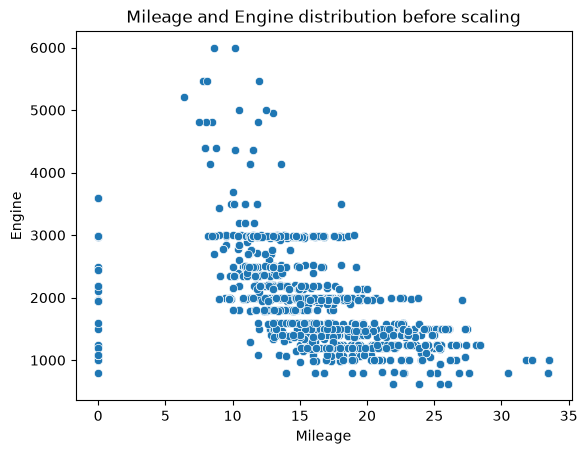

In [134]:
plt.title("Mileage and Engine distribution before scaling")
sns.scatterplot(x='Mileage', y='Engine', data=data)

In [135]:
# Scaled with MinMax Scaler
from sklearn.preprocessing import MinMaxScaler

In [136]:
scaler = MinMaxScaler()

In [142]:
df = data[['Mileage','Engine','Power']]

In [143]:
df.head()

,Mileage,Engine,Power
0,26.60,998.0,58.16
1,19.67,1582.0,126.20
2,18.20,1199.0,88.70
3,20.77,1248.0,88.76
4,15.20,1968.0,140.80


In [145]:
# scaled the data 'df'
df_minmax=scaler.fit_transform(df)

In [146]:
df_minmax

array([[0.79308289, 0.15626055, 0.04118254],
       [0.58646392, 0.25480931, 0.15812994],
       [0.54263566, 0.19017887, 0.0936748 ],
       ...,
       [0.68813357, 0.23439082, 0.04967343],
       [0.51282051, 0.18984138, 0.11928498],
       [0.29815146, 0.35032062, 0.23341354]], shape=(7253, 3))

In [147]:
# convert array 'df_minmax' to dataframe
df_minmax = pd.DataFrame(df_minmax, columns = df.columns)

In [148]:
df_minmax

,Mileage,Engine,Power
0,0.793083,0.156261,0.041183
1,0.586464,0.254809,0.158130
2,0.542636,0.190179,0.093675
3,0.619261,0.198448,0.093778
4,0.453190,0.319946,0.183224
...,...,...,...
7248,0.612403,0.257509,0.119285
7249,0.513119,0.189841,0.119285
7250,0.688134,0.234391,0.049673
7251,0.512821,0.189841,0.119285


Text(0.5, 1.0, 'Scatter plot after scaling (MinMax scaler)')

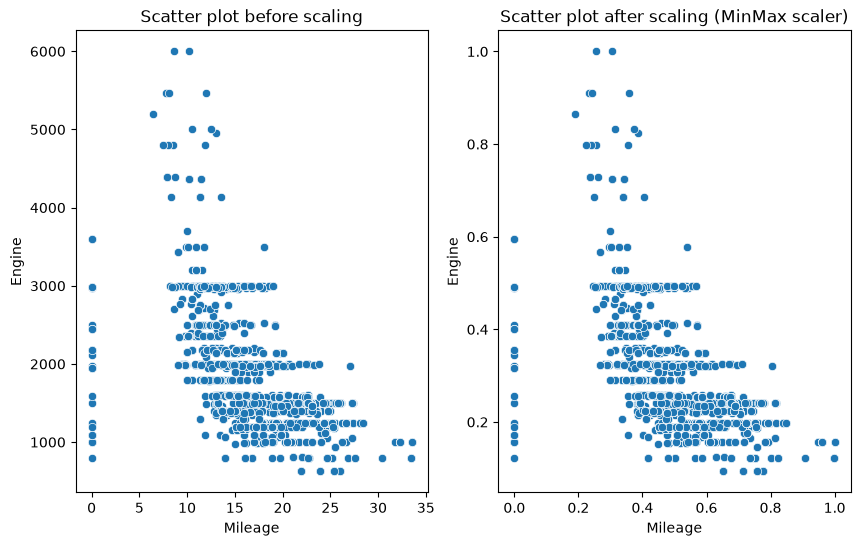

In [152]:
fig, axes = plt.subplots(1,2, figsize=(10,6))
sns.scatterplot(x='Mileage', y='Engine', data=data, ax=axes[0])
axes[0].set_title("Scatter plot before scaling")
sns.scatterplot(x='Mileage', y='Engine', data=df_minmax, ax=axes[1])
axes[1].set_title("Scatter plot after scaling (MinMax scaler)")

In [153]:
# plot in correlation 
data[['Mileage','Engine']].corr()

,Mileage,Engine
Mileage,1.000000,-0.593569
Engine,-0.593569,1.000000


In [154]:
df_minmax[['Mileage','Engine']].corr()

,Mileage,Engine
Mileage,1.000000,-0.593569
Engine,-0.593569,1.000000


Text(0.5, 1.0, 'After scaling')

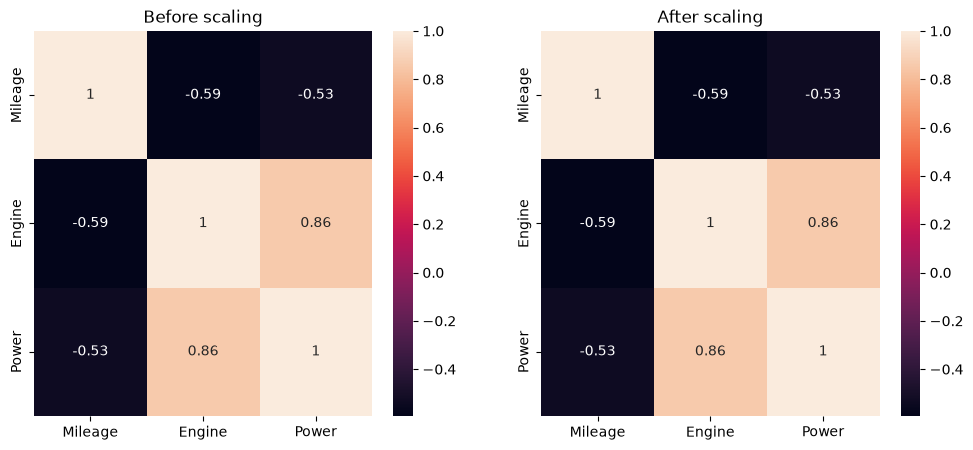

In [160]:
# plot in co-relation
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(df.corr(), annot=True, ax=axes[0])
sns.heatmap(df_minmax.corr(), annot=True, ax=axes[1])
axes[0].set_title("Before scaling")
axes[1].set_title("After scaling")


In [162]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler

In [163]:
ss_scaler = StandardScaler()

In [164]:
df

,Mileage,Engine,Power
0,26.60,998.0,58.16
1,19.67,1582.0,126.20
2,18.20,1199.0,88.70
3,20.77,1248.0,88.76
4,15.20,1968.0,140.80
...,...,...,...
7248,20.54,1598.0,103.60
7249,17.21,1197.0,103.60
7250,23.08,1461.0,63.10
7251,17.20,1197.0,103.60


In [166]:
ss_scaled = ss_scaler.fit_transform(df)
ss_scaled

array([[ 1.85415132, -1.03919341, -1.02085333],
       [ 0.33504144, -0.05808287,  0.2511655 ],
       [ 0.01280601, -0.70151666, -0.44990308],
       ...,
       [ 1.08253995, -0.26136091, -0.92849923],
       [-0.20640176, -0.70487663, -0.17134516],
       [-1.78469773,  0.89278796,  1.0700136 ]], shape=(7253, 3))

In [167]:
df_ss_scaled = pd.DataFrame(ss_scaled, columns = df.columns)

In [168]:
df_ss_scaled

,Mileage,Engine,Power
0,1.854151,-1.039193,-1.020853
1,0.335041,-0.058083,0.251166
2,0.012806,-0.701517,-0.449903
3,0.576170,-0.619197,-0.448781
4,-0.644817,0.590391,0.524115
...,...,...,...
7248,0.525752,-0.031203,-0.171345
7249,-0.204210,-0.704877,-0.171345
7250,1.082540,-0.261361,-0.928499
7251,-0.206402,-0.704877,-0.171345


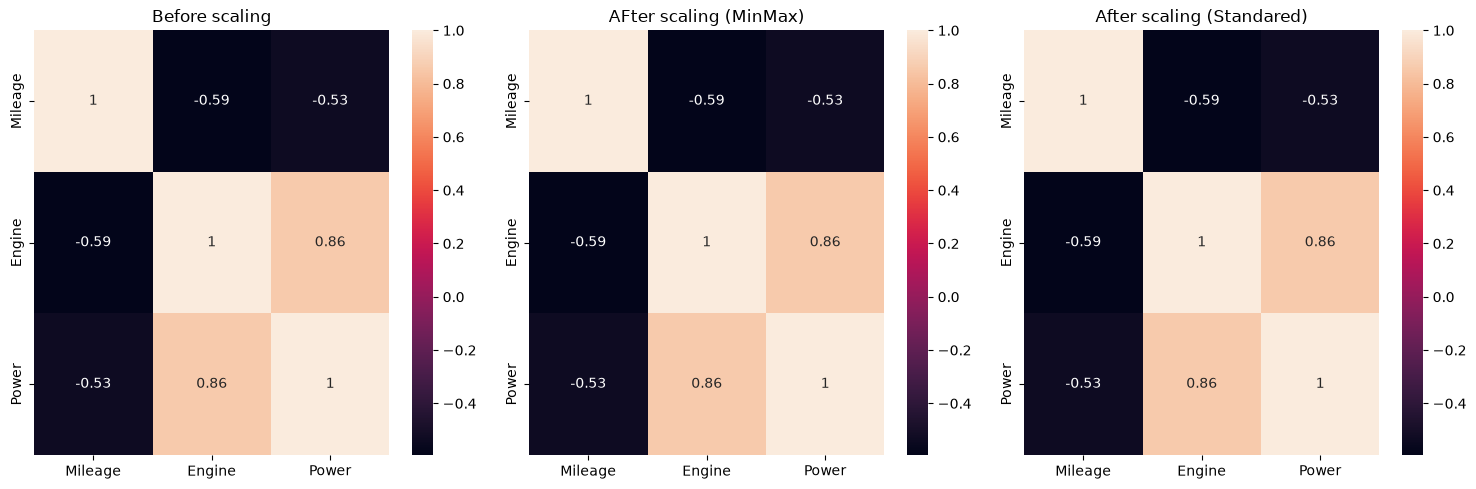

In [170]:
# Show the relation in Heatmap
# plot in co-relation
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.heatmap(df.corr(), annot=True, ax=axes[0])
sns.heatmap(df_minmax.corr(), annot=True, ax=axes[1])
sns.heatmap(df_ss_scaled.corr(), annot=True, ax=axes[2])
axes[0].set_title("Before scaling")
axes[1].set_title("AFter scaling (MinMax)")
axes[2].set_title("After scaling (Standared)")
plt.tight_layout()

In [171]:
df_ss_scaled.corr()

,Mileage,Engine,Power
Mileage,1.000000,-0.593569,-0.531771
Engine,-0.593569,1.000000,0.859771
Power,-0.531771,0.859771,1.000000


In [179]:
# check 'std' value for 'df_ss_scaled' dataset
df_ss_scaled.agg(['std']) # std value is always 1

,Mileage,Engine,Power
std,1.000069,1.000069,1.000071


In [180]:
df_minmax.corr()

,Mileage,Engine,Power
Mileage,1.000000,-0.593569,-0.531771
Engine,-0.593569,1.000000,0.859771
Power,-0.531771,0.859771,1.000000


In [181]:
# check min, max value for 'df_minmax' dataset
df_minmax.agg(['min','max']) # min 0 and max 1 

,Mileage,Engine,Power
min,0.0,0.0,0.0
max,1.0,1.0,1.0


In [182]:
# most frequestn mileage value
data.Mileage.mode()

0    17.0
Name: Mileage, dtype: float64

In [184]:
data[data['Mileage']==17.0]

,Location,run,Name,fule,Transmission,Mileage,Engine,Power,price,Price,brand,model,Transmission_encoded,location encoded,model_encoded
89,Hyderabad,73745,Hyundai Santro Xing XO,Petrol,Manual,17.0,1086.0,NaN,NaN,2.10,Hyundai,Santro,1,5,164
104,Pune,66000,Hyundai i20 2015-2017 Asta,Petrol,Manual,17.0,1197.0,80.00,NaN,2.70,Hyundai,i20,1,10,215
120,Mumbai,102000,Hyundai Santro Xing XL eRLX Euro III,Petrol,Manual,17.0,1086.0,NaN,NaN,0.85,Hyundai,Santro,1,9,164
135,Kochi,12645,Hyundai Verna VTVT 1.6 AT SX Plus,Petrol,Automatic,17.0,1591.0,121.30,13.49 Lakh,11.50,Hyundai,Verna,2,7,189
143,Kochi,80759,Hyundai Santro Xing XO eRLX Euro II,Petrol,Manual,17.0,1086.0,NaN,NaN,1.67,Hyundai,Santro,1,7,164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7092,Coimbatore,64168,Hyundai Santro Xing XG AT eRLX Euro III,Petrol,Automatic,17.0,1086.0,NaN,NaN,NaN,Hyundai,Santro,2,3,164
7118,Hyderabad,60268,Honda City 1.5 S MT,Petrol,Manual,17.0,1497.0,118.00,NaN,NaN,Honda,City,1,5,45
7139,Kolkata,36200,Hyundai i20 1.2 Sportz Option,Petrol,Manual,17.0,1197.0,80.00,NaN,NaN,Hyundai,i20,1,8,215
7184,Mumbai,18980,Hyundai Verna VTVT 1.6 AT SX Option,Petrol,Automatic,17.0,1591.0,121.30,15.14 Lakh,NaN,Hyundai,Verna,2,9,189


In [185]:
data.Mileage.median()

np.float64(18.16)

In [186]:
data.Mileage.mean()

np.float64(18.141580471659083)

<Axes: xlabel='Mileage', ylabel='Density'>

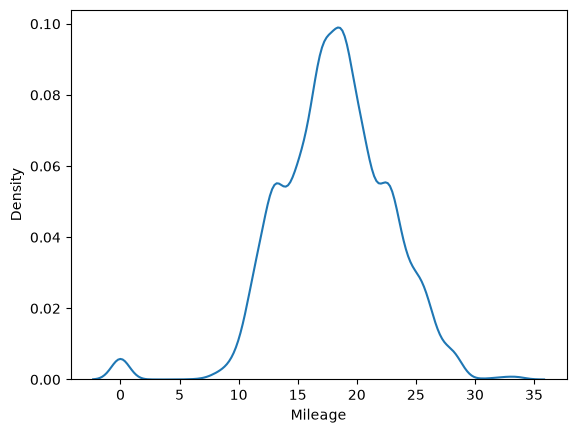

In [187]:
sns.kdeplot(x='Mileage', data=data)

In [188]:
# Range min-max
ma = data.Mileage.max()
mi = data.Mileage.min()

In [189]:
range = ma - mi
range

np.float64(33.54)

In [190]:
# variance
data.Mileage.var()

np.float64(20.81363783279928)

In [191]:
# std
data.Mileage.std()

np.float64(4.562196601725892)

In [192]:
# Quantile
q1 = data.Mileage.quantile(0.25)
q1

np.float64(15.17)

In [194]:
q3 = data.Mileage.quantile(0.75)
q3

np.float64(21.1)

In [196]:
# 90 percentiles of data
q90 = data.Mileage.quantile(0.90)
q90

np.float64(24.0)

In [197]:
data.Mileage.skew()

np.float64(-0.4383205657235177)

<Axes: xlabel='Mileage', ylabel='Density'>

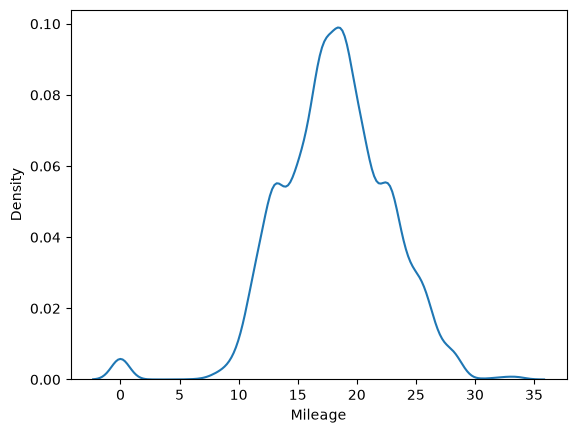

In [198]:
sns.kdeplot(x='Mileage', data=data)